# Ejercicios de Seaborn

# 1. Importa pandas, pyplot y seaborn

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 3. Lee 'Pokemon.csv', lee la primera columna del csv como índice del DataFrame

In [143]:
pokemons = pd.read_csv(".\\data\\Pokemon.csv")

# 4. Mira las primeras filas del dataset para hacerte una idea de los datos cargados

In [144]:
pokemons.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
3,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
4,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False


# 5. Haz un scatter plot con lmplot(), que es el método que pinta una regresión lineal
### Pasa el DataFrame como argumento del método en el parámetro llamado data

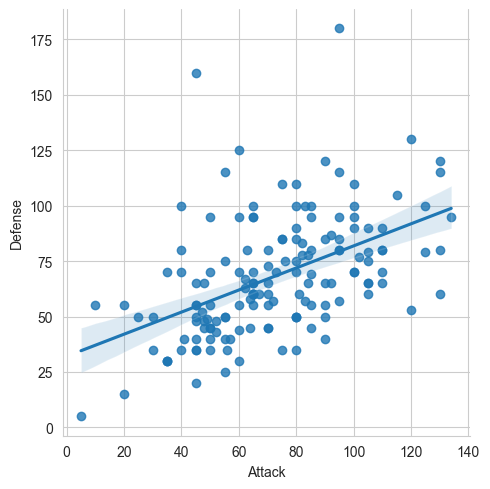

In [145]:
sns.lmplot(data=pokemons, x="Attack", y="Defense", fit_reg=True, legend=True);

# 6. No queremos ver la línea recta de la regresión lineal.
### prueba a añadir fit_reg a falso

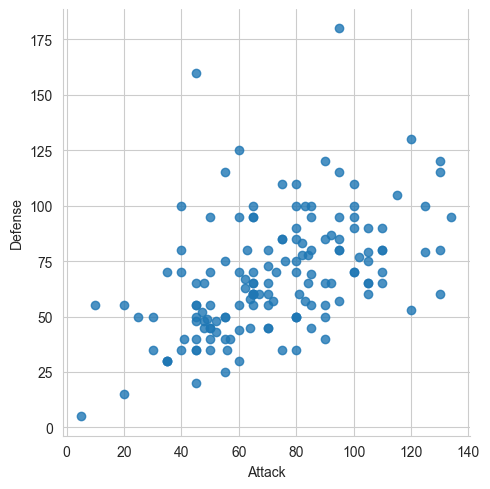

In [146]:
sns.lmplot(data=pokemons, x="Attack", y="Defense", fit_reg=False);

# 7. Vamos a decir qué variable (columna del DataFrame) codifica los colores (hue)
### Que el hue sea el Stage

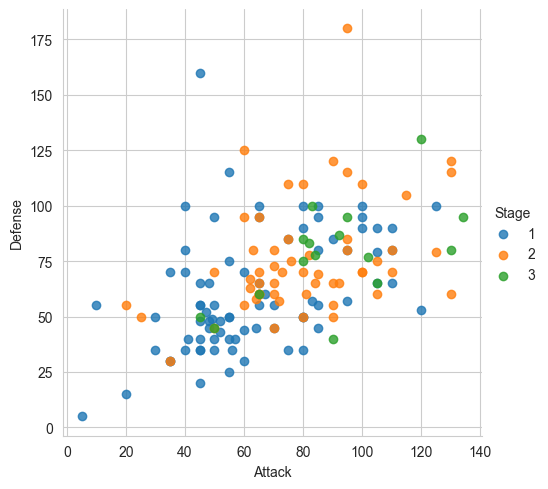

In [147]:
sns.lmplot(data=pokemons, x="Attack", y="Defense", fit_reg=False, hue="Stage");

# 8. Limita el eje x entre 20 y 100

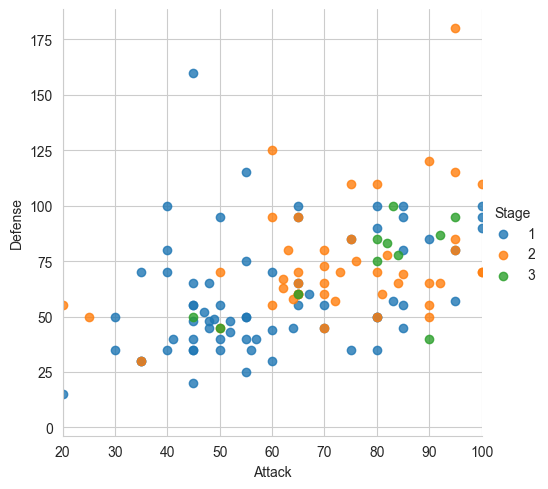

In [148]:
graf = sns.lmplot(data=pokemons, x="Attack", y="Defense", fit_reg=False, hue="Stage",);
plt.xlim(20, 100);
#graf.set(xlim=(20, 100));

# 9. Dibuja un diagrama de cajas con el dataframe

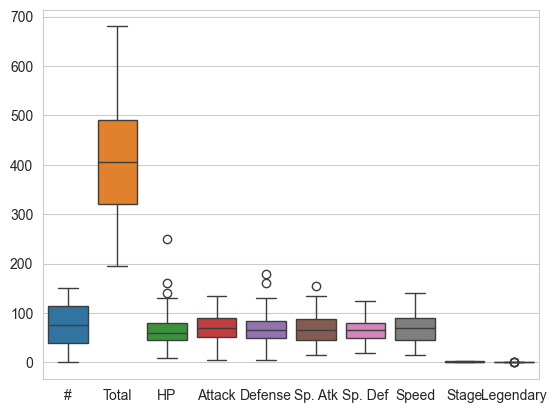

In [149]:
sns.boxplot(data=pokemons);

# 10. No nos interesan las columnas Total, Stage ni Legendary
### Bórralos del DataFrame y vuelve a dibujar el diagrama de cajas

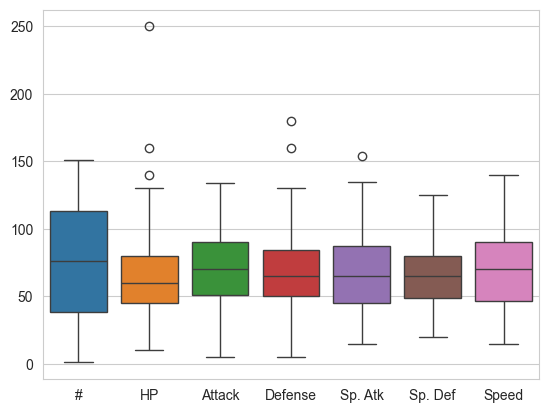

In [150]:
data_drop = pokemons.drop(columns=["Legendary", "Stage", "Total"])
sns.boxplot(data=data_drop);

# 11. Mira cuántos 'Type 1' diferentes hay en el DataFrame

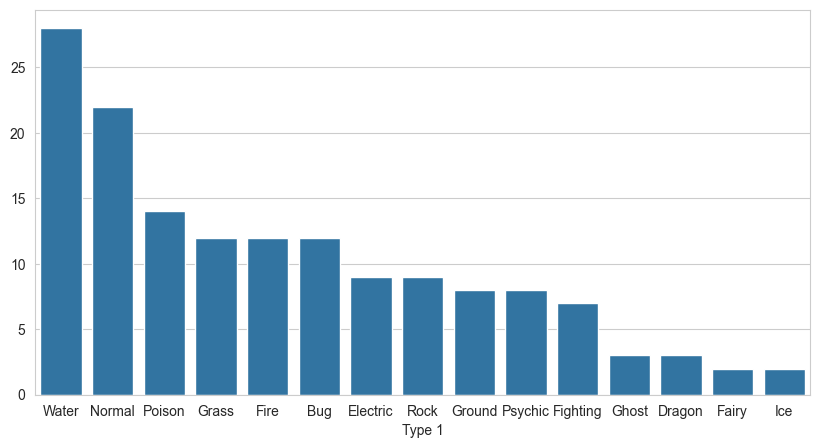

In [151]:
type1 = pokemons["Type 1"].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=type1.index, y=type1.values);

# 12. Quédate del Dataframe solo con los 'Type 1' iguales a 'Grass', 'Fire' o 'Water'

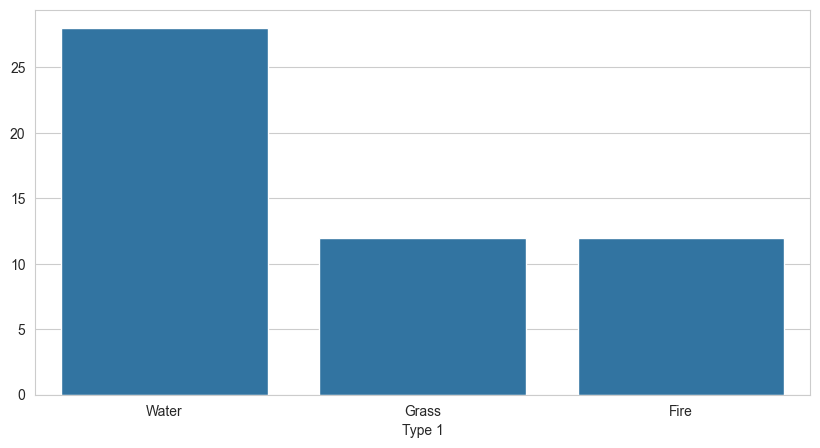

In [152]:
plt.figure(figsize=(10, 5))
types_filter = pokemons[pokemons["Type 1"].isin(['Grass', 'Fire', 'Water'])]["Type 1"].value_counts()
sns.barplot(x=types_filter.index, y=types_filter.values);

# 13. Usa un estilo 'whitegrid'

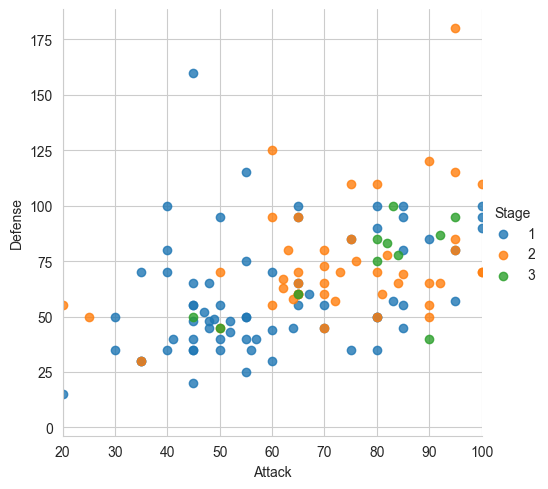

In [153]:
graf = sns.lmplot(data=pokemons, x="Attack", y="Defense", fit_reg=False, hue="Stage",);
plt.xlim(20, 100);
sns.set_style("whitegrid");


# 14. Pinta diagramas de violín con el DataFrame filtrado por los 3 tipos

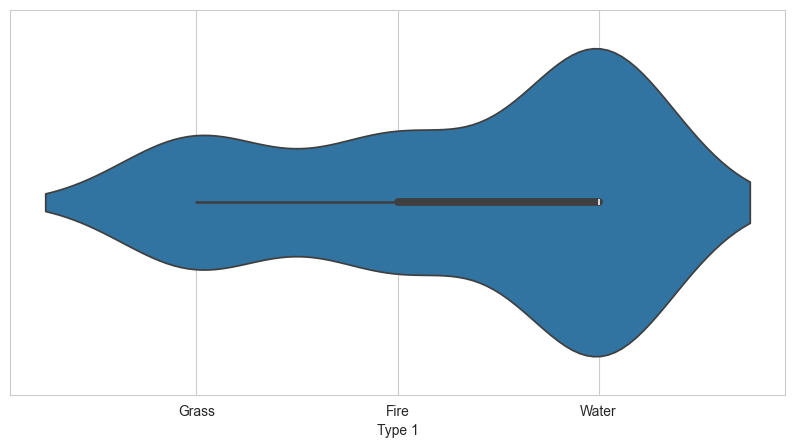

In [154]:
plt.figure(figsize=(10, 5))
types_filter = pokemons[pokemons["Type 1"].isin(['Grass', 'Fire', 'Water'])]
sns.violinplot(x=types_filter["Type 1"]);


# 15. Escribe una lista de colores con valores '#78C850', '#F08030',  '#6890F0'

In [155]:
colors = ['#78C850', '#F08030',  '#6890F0']


# 16. Pinta de nuevo los diagramas de violín añadiendo esos colores en la paleta (palette)

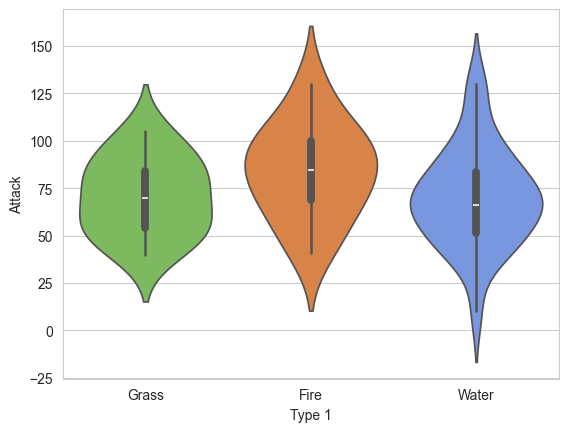

In [156]:
sns.violinplot(data=types_filter, x="Type 1", y="Attack", hue="Type 1", palette=colors, legend=False);

# 17. Con el diagrama de violín vemos la forma de la distribución, pero no sabemos si Grass tiene muchos puntos y Fire tiene muy pocos.
### Para ver esto, usamos el swarmplot.
### Pinta el último diagrama de violines pero con un swarmplot en lugar de un violin

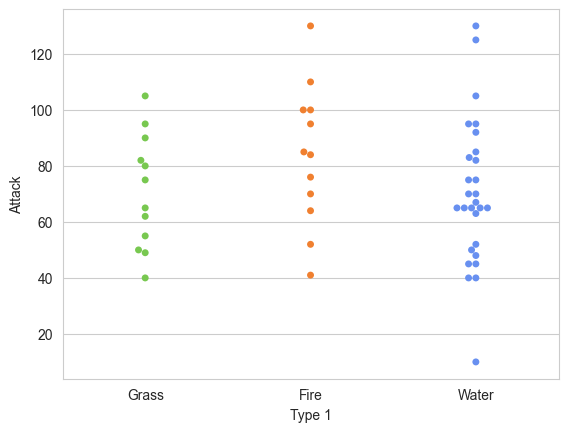

In [157]:
sns.swarmplot(data=types_filter, x="Type 1", y="Attack", hue="Type 1", palette=colors);
#sns.violinplot(data=types_filter, x="Type 1", y="Attack", hue="Type 1", palette=colors, inner="point", legend=True);



# 18. Queremos ver los violines a la vez que los swarm, los podemos pintar juntos. 
### Elimina los diagramas de caja dentro de los violines con el parámetro inner = None y pon una transparencia de 0.9 en el swarmplot
### Pon un título con pyplot (como siempre)

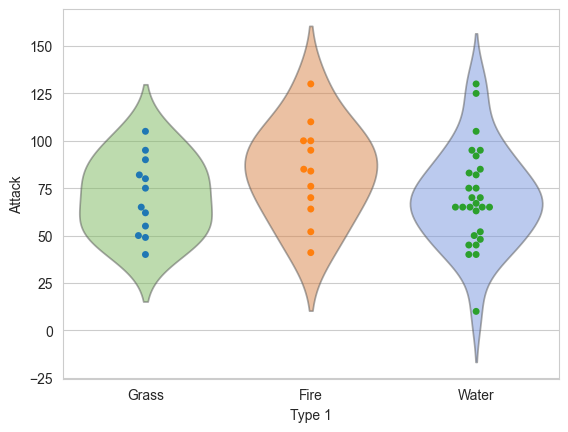

In [158]:
sns.swarmplot(data=types_filter, x="Type 1", y="Attack", hue="Type 1");
sns.violinplot(data=types_filter, x="Type 1", y="Attack", hue="Type 1", palette=colors, alpha=0.5, legend=False, inner=None);

# 19. Veamos la función melt() de pandas. Melt toma los valores de varias columnas y los junta todos en una misma columna nueva.
### Dado un DataFrame, melt recibe varios parámetros:
### * qué columnas del DataFrame se quedan igual
### * qué nombres de columnas del dataframe pasan a ser una columna nueva
### * cómo queremos llamar esas nuevas columnas

### Primero recuerda el Dataframe df_grass_fire_water con las primeras 5 filas

In [166]:
pokemons_melt = pokemons.melt(id_vars=["Name", "Type 1"], value_name="Value", value_vars=["Attack", "Defense", "HP"]).sort_values("Name", ascending=False)
pokemons_melt

,Name,Type 1,variable,Value
342,Zubat,Poison,HP,40
40,Zubat,Poison,Attack,45
191,Zubat,Poison,Defense,35
295,Zapdos,Electric,Defense,85
446,Zapdos,Electric,HP,90
...,...,...,...,...
141,Aerodactyl,Rock,Attack,105
292,Aerodactyl,Rock,Defense,65
213,Abra,Psychic,Defense,15
364,Abra,Psychic,HP,25


# 20. Queremos dejar igual las variables 'Name' y 'Type 1'
### Queremos añadir una columa nueva cuyos valores sean las columnas que queremos apilar y que se llame 'New Column'
### Escribimos df_gfw.melt(id_vars=['Name', 'Type 1'], value_vars=[...], var_name='New Column')

In [167]:
pokemons_melt = pokemons.melt(id_vars=["Name", "Type 1"], value_name="New Column", value_vars=["Attack", "Defense", "HP"]).sort_values("Name", ascending=False)
pokemons_melt

,Name,Type 1,variable,New Column
342,Zubat,Poison,HP,40
40,Zubat,Poison,Attack,45
191,Zubat,Poison,Defense,35
295,Zapdos,Electric,Defense,85
446,Zapdos,Electric,HP,90
...,...,...,...,...
141,Aerodactyl,Rock,Attack,105
292,Aerodactyl,Rock,Defense,65
213,Abra,Psychic,Defense,15
364,Abra,Psychic,HP,25


# 21. Pintamos el swarmplot con el melted y entendemos la información

c:\Users\jlalo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jlalo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


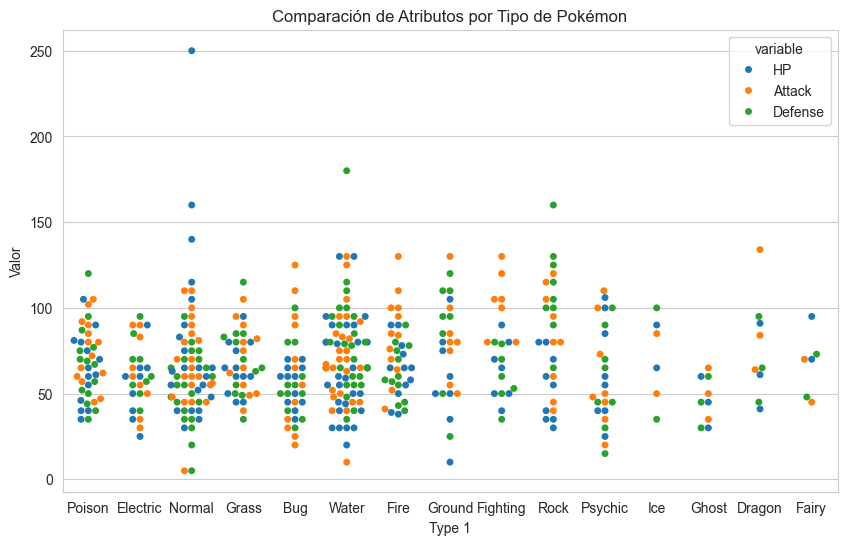

In [168]:
plt.figure(figsize=(10, 6))
sns.swarmplot(data=pokemons_melt, x="Type 1", y="New Column", hue="variable")
plt.title("Comparación de Atributos por Tipo de Pokémon")
plt.ylabel("Valor")
plt.show()

# 22. Basándote en el gráfico anterior, define el tamaño de la figura en (10,6) (usa plt)
### En el swarmplot añade el argumento dodge a True y usa la anterior paleta de colores Pokemon

### Dodge en inglés es "esquivar", ¿qué diferencia ves?

## Usando plt 
### fija el límite del eje Y entre 0 y 200
### fija la leyenda con bbox_to_anchor en upper left. Pista: upper left es el código 2 y se usa el parámetro loc.

### Observa que incluso usando Seaborn, usamos Pyplot para trabajar con los ejes, la leyenda y el tamaño
### Lo importante es que Seaborn y Pyplot conviven bien juntos

c:\Users\jlalo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(0.5, 1.0, 'Comparación de Atributos por Tipo de Pokémon')

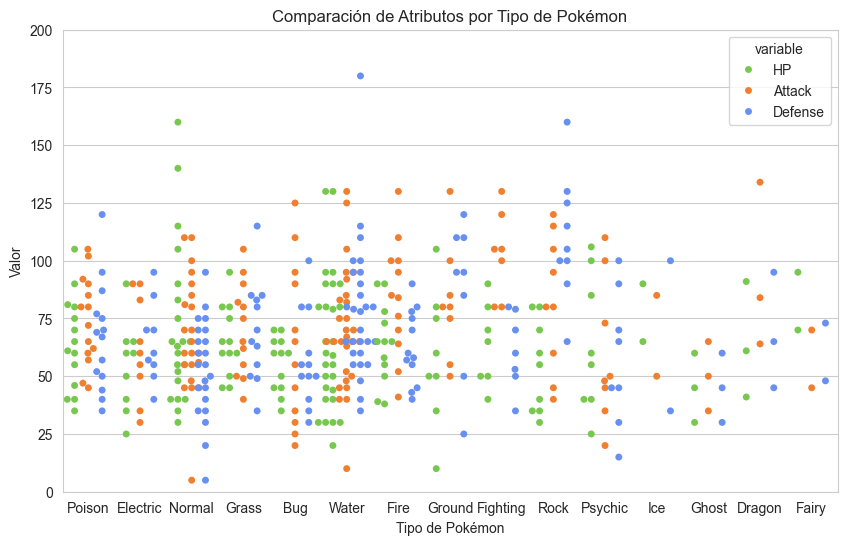

In [172]:
plt.figure(figsize=(10, 6))
sns.swarmplot(data=pokemons_melt, x="Type 1", y="New Column", hue="variable", palette=colors, dodge=True);
plt.xlabel("Tipo de Pokémon")
plt.ylabel("Valor")
plt.ylim(0, 200)
plt.title("Comparación de Atributos por Tipo de Pokémon")

# 23. Mapas de calor
### Calcula las correlaciones del primer DataFrame original df
### Pista: las correlaciones se calculan con el método corr()
### Recuerda: las correlaciones miden entre dos variables, si varío una, cuánto me varía la otra (cómo están de relacionadas)

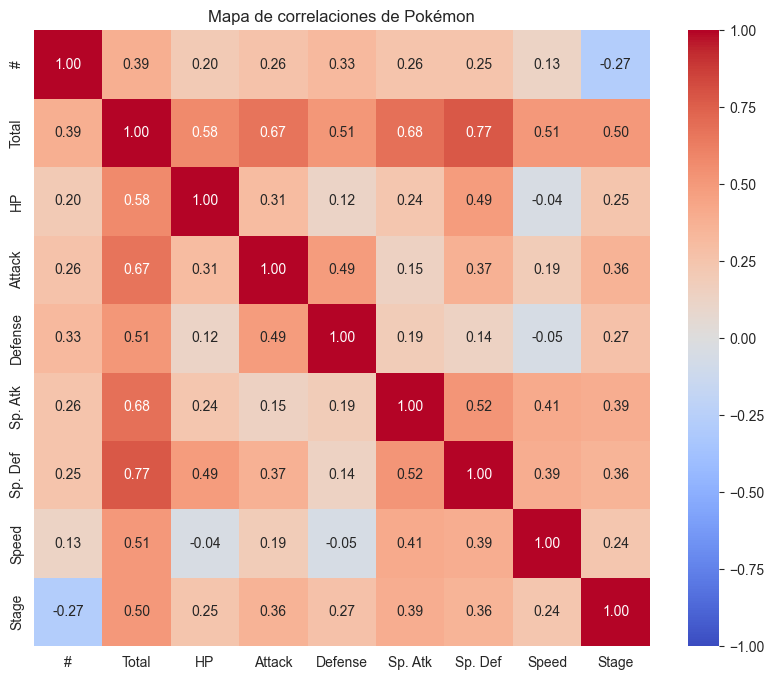

In [176]:
# Calcular correlaciones (solo columnas numéricas)
corr = pokemons.select_dtypes(include='number').corr()
#print(corr)
# Visualizar con heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Mapa de correlaciones de Pokémon")
plt.show()

### ¿la correlación entre qué valores se encuentra?
### la autocorrelación es la correlación de una variable consigo misma, ¿qué aprecias?
### Encuentra dos variables que veas que están fuertemente relacionadas según la correlación

La correlación mas fuerte es entre sp.Def con un 0.77 y en genera con toda la columna de totales lo que tiene cierto sentido pero no parece significativo.

# 24. Pinta el histograma y la densidad de probabilidad del nivel de defensa usando el DataFrame original

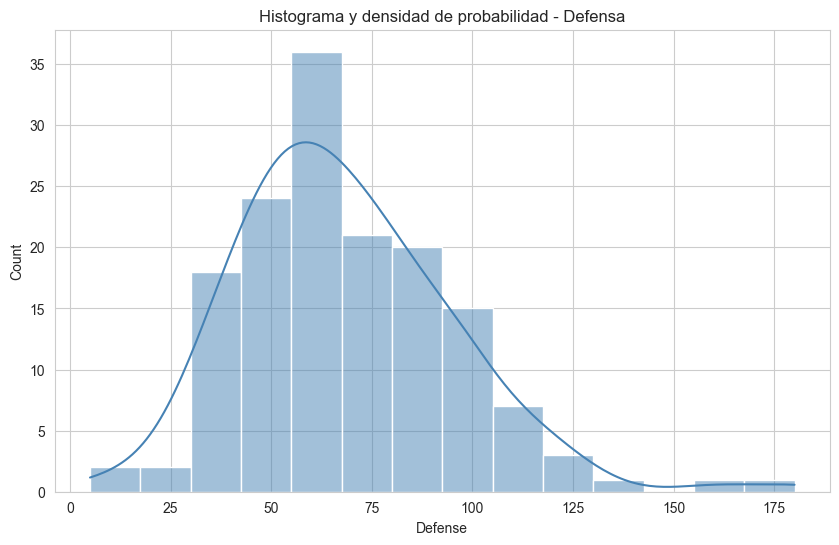

In [178]:
plt.figure(figsize=(10, 6))
sns.histplot(data=pokemons, x="Defense", kde=True, color="steelblue")
plt.title("Histograma y densidad de probabilidad - Defensa")
plt.show()

# 25. Pinta un diagrama de barras de la columna 'Type 1' usando el DataFrame original
### Usa un sns.countplot
### Usa plt.xticks y gira las etiquetas

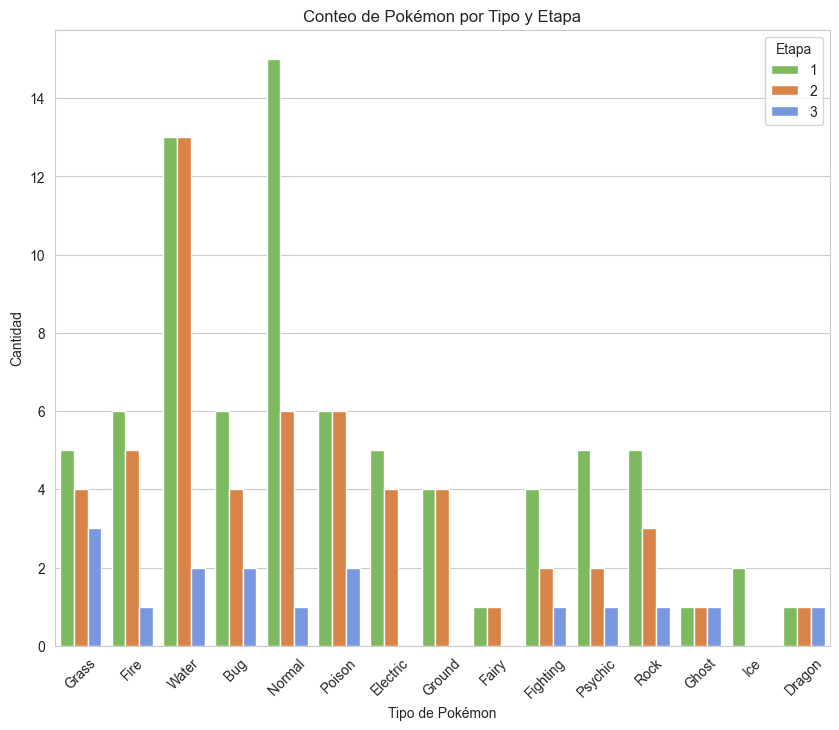

In [181]:
plt.figure(figsize=(10, 8))
sns.countplot(data=pokemons, x="Type 1", hue="Stage", palette=colors)
plt.title("Conteo de Pokémon por Tipo y Etapa")
plt.xlabel("Tipo de Pokémon")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.legend(title="Etapa")
plt.show();

# 26. Usa catplot con el DataFrame original.
### Muestra el valor de Defense según el 'Type 1', muestra un subplot para legendarios y otro para no legendarios y divide los colores según el Type 2

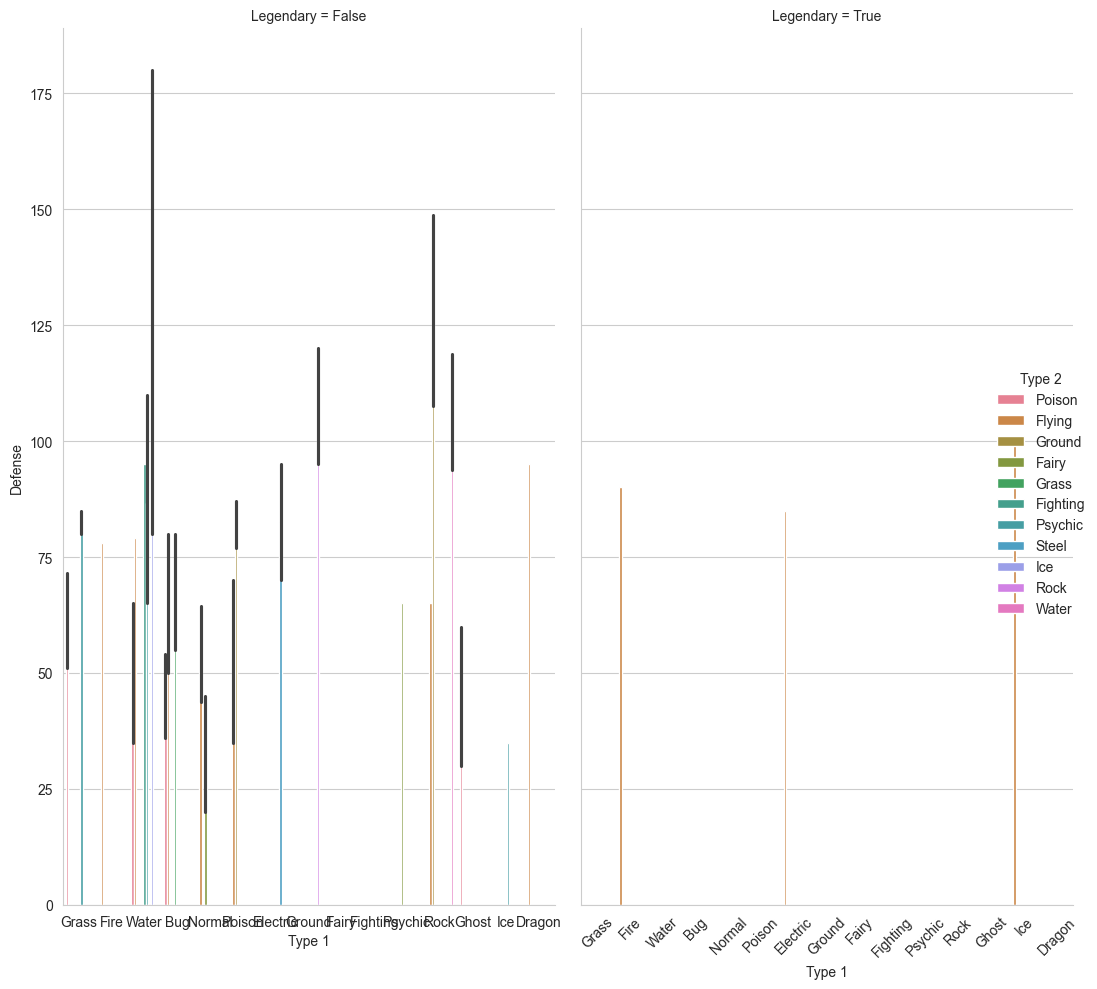

In [190]:
sns.catplot(
    data=pokemons,
    x="Type 1",
    y="Defense",
    hue="Type 2",
    col="Legendary",# subplot por legendario/no legendario
    kind="bar",
    height=10,
    aspect=0.5
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 27. Muestra una función distribución de probabilidad con kdeplot (curvas de nivel) de la defensa respecto al ataque.
### Di un bin 2D donde caigan muchos puntos (ataque, defensa).

<Axes: xlabel='Attack', ylabel='Defense'>

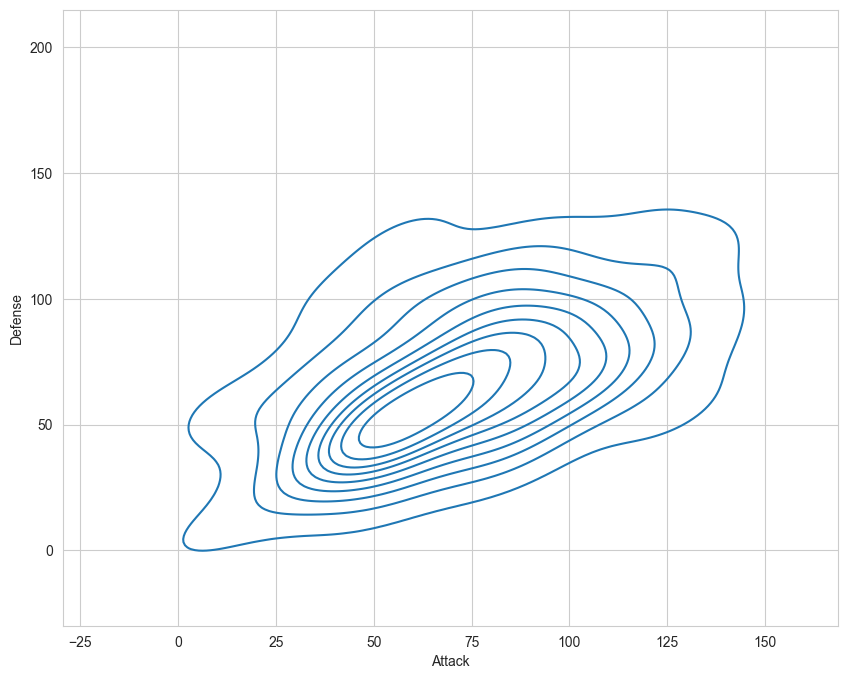

In [198]:
plt.figure(figsize=(10, 8))
sns.kdeplot(data=pokemons, 
            x="Attack", 
            y="Defense",  
            thresh=0.05
            )

# 28. Pinta una distribución de probabilidad conjunta con jointplot, pintando la defensa respecto al ataque del DataFrame original

<Figure size 1000x800 with 0 Axes>

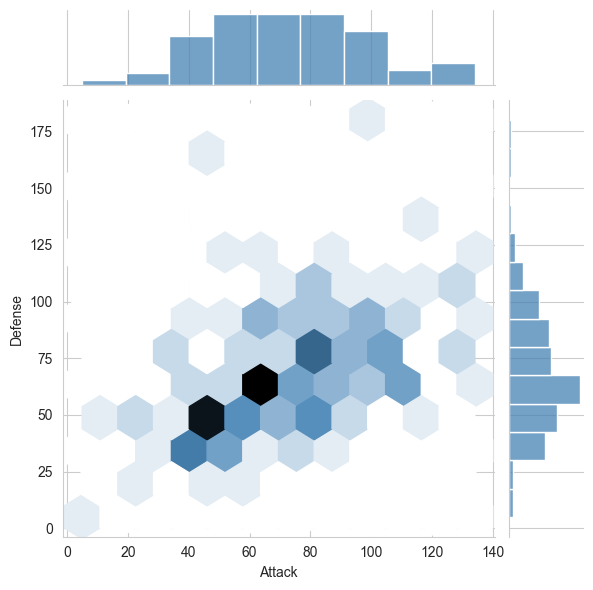

In [200]:
plt.figure(figsize=(10, 8));
sns.jointplot(data=pokemons, x="Attack", y="Defense", kind="hex", color="steelblue");